In [97]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
df_sp = pd.read_csv('dump.csv', encoding = 'utf-8')
df_sp.head()

,Название,Артикул,Категория,Цена без карты,Цена с картой
0,Проходка BORGE Кровельная D6-50мм прямая №1,17162301,"Главная,Каталог,Строительные материалы,Кровля,...",329.33 ₽,312.86 ₽
1,Аэратор ТЕХНОНИКОЛЬ КТВ,17575401,"Главная,Каталог,Строительные материалы,Кровля,...",1 529.00 ₽,1 452.55 ₽
2,Аэратор ТЕХНОНИКОЛЬ Pilot скатный,17575301,"Главная,Каталог,Строительные материалы,Кровля,...",3 008.00 ₽,2 857.60 ₽
3,Проходной элемент ТЕХНОНИКОЛЬ Shinglas,17575701,"Главная,Каталог,Строительные материалы,Кровля,...",1 172.00 ₽,1 113.40 ₽
4,Вентиль ТЕХНОНИКОЛЬ Skat кровельный,17575501,"Главная,Каталог,Строительные материалы,Кровля,...",2 396.00 ₽,2 276.20 ₽


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/mugichu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
<ipython-input-98-bcfb2f066c91>:38: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 1)


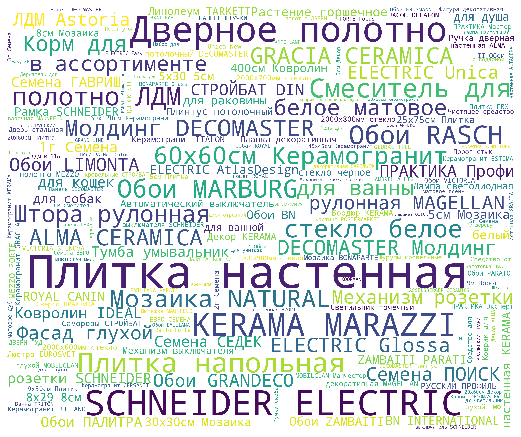

In [98]:
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
from string import punctuation
russian_stopwords = stopwords.words("russian")

def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus
# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus
# Получение облака слов
def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(str_corpus(corpus))
    return wordCloud

corpus = get_corpus(df_sp['Название'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

In [99]:
def remove_punct(text):
    table = {33: ' ', 34: ' ', 35: ' ', 36: ' ', 37: ' ', 38: ' ', 39: ' ', 40: ' ', 41: ' ', 42: ' ', 43: ' ', 44: ' ', 45: ' ', 46: ' ', 47: ' ', 58: ' ', 59: ' ', 60: ' ', 61: ' ', 62: ' ', 63: ' ', 64: ' ', 91: ' ', 92: ' ', 93: ' ', 94: ' ', 95: ' ', 96: ' ', 123: ' ', 124: ' ', 125: ' ', 126: ' '}
    return text.translate(table)

df_sp['Название_чистое'] = df_sp['Название'].map(lambda x: x.lower())
df_sp['Название_чистое'] = df_sp['Название_чистое'].map(lambda x: remove_punct(x))
df_sp['Название_чистое'] = df_sp['Название_чистое'].map(lambda x: x.split(' '))
df_sp['Название_чистое'] = df_sp['Название_чистое'].map(lambda x: [token for token in x if token not in russian_stopwords\
                                                                  and token != " " \
                                                                  and token.strip() not in punctuation])
df_sp['Название_чистое'] = df_sp['Название_чистое'].map(lambda x: ' '.join(x))

<ipython-input-100-b26688fd6d5f>:8: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 1)


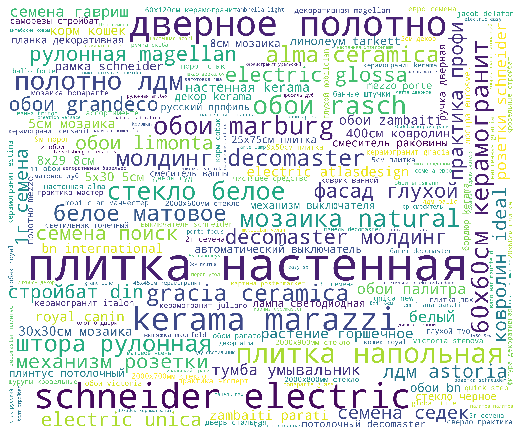

In [100]:
corpus = get_corpus(df_sp['Название_чистое'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

In [114]:
df_sp_clean = df_sp.loc[df_sp['Категория'].isin([
              'Главная,Каталог,Строительные материалы,Кровля,Вентиляция для кровли',
          'Главная,Каталог,Строительные материалы,Кровля,Волнистый лист (ондулин)',
          'Главная,Каталог,Строительные материалы,Кровля,Кровельные мастики',
          'Главная,Каталог,Строительные материалы,Кровля,Кровельные ограждения, снегодержатели',
          'Главная,Каталог,Строительные материалы,Кровля,Металлочерепица',
          'Главная,Каталог,Строительные материалы,Кровля,Мягкая черепица',
          'Главная,Каталог,Строительные материалы,Кровля,Профнастил',
          'Главная,Каталог,Строительные материалы,Кровля,Рулонная кровля',
          'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Затирки',
          'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Клеи',
          'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Ровнители для пола',
          'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Специальные смеси',
          'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Шпаклевки',
          'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Штукатурки',
          'Главная,Каталог,Строительные материалы,Строительство из ГКЛ,Гипсокартон',
          'Главная,Каталог,Строительные материалы,Строительство из ГКЛ,Комплектующие для гипсокартона',
          'Главная,Каталог,Строительные материалы,Строительство из ГКЛ,Профиль для гипсокартона',
          'Главная,Каталог,Строительные материалы,Материалы для кладки,Кирпич',
          'Главная,Каталог,Строительные материалы,Материалы для кладки,Пазогребневые блоки и плиты',
          'Главная,Каталог,Строительные материалы,Материалы для кладки,Пенобетонные блоки',
          'Главная,Каталог,Строительные материалы,Металлическая арматура',
          'Главная,Каталог,Строительные материалы,Столярные изделия,Вагонка,  блок-хаус',
          'Главная,Каталог,Строительные материалы,Столярные изделия,Двери жалюзийные',
          'Главная,Каталог,Строительные материалы,Столярные изделия,Деревянные окна',
          'Главная,Каталог,Строительные материалы,Столярные изделия,Доска для пола и комплектующие',
          'Главная,Каталог,Строительные материалы,Столярные изделия,Доска обрезная',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Специальный крепеж',
          'Главная,Каталог,Строительные материалы,Столярные изделия,Лестничные группы',
          'Главная,Каталог,Строительные материалы,Столярные изделия,Погонажные изделия',
          'Главная,Каталог,Строительные материалы,Листовые материалы,OSB',
          'Главная,Каталог,Строительные материалы,Листовые материалы,ДВП',
          'Главная,Каталог,Строительные материалы,Листовые материалы,ДСП',
          'Главная,Каталог,Строительные материалы,Листовые материалы,Металлические листы',
          'Главная,Каталог,Строительные материалы,Листовые материалы,Пластик',
          'Главная,Каталог,Строительные материалы,Листовые материалы,Фанера',
          'Главная,Каталог,Строительные материалы,Материалы для изоляции,Гидроизоляционные материалы',
          'Главная,Каталог,Строительные материалы,Материалы для изоляции,Лента изоляционная и соединительная',
          'Главная,Каталог,Строительные материалы,Материалы для изоляции,Материалы для осушения и защиты от солей кладок старых зданий',
          'Главная,Каталог,Строительные материалы,Материалы для изоляции,Минеральная теплоизоляция',
          'Главная,Каталог,Строительные материалы,Материалы для изоляции,Пенопласт',
          'Главная,Каталог,Строительные материалы,Материалы для изоляции,Пенополистирол',
          'Главная,Каталог,Строительные материалы,Материалы для изоляции,Плёнки и утеплители',
          'Главная,Каталог,Строительные материалы,Материалы для изоляции,Поролон и войлок',
          'Главная,Каталог,Строительные материалы,Материалы для изоляции,Рулонные и битумные кровельные материалы',
          'Главная,Каталог,Строительные материалы,Материалы для изоляции,Уплотнители',
          'Главная,Каталог,Строительные материалы,Материалы для тротуара и ограждение,Бордюры тротуарные и водостоки',
          'Главная,Каталог,Строительные материалы,Материалы для тротуара и ограждение,Водостоки и дренаж',
          'Главная,Каталог,Строительные материалы,Материалы для тротуара и ограждение,Кольца и колодцы',
          'Главная,Каталог,Строительные материалы,Материалы для тротуара и ограждение,Плитка тротуарная и формы',
          'Главная,Каталог,Строительные материалы,Материалы для тротуара и ограждение,Решетки водоприемные',
          'Главная,Каталог,Строительные материалы,Материалы для тротуара и ограждение,Трубы канализационные',
          'Главная,Каталог,Строительные материалы,Материалы для фасадов,Калитки и ограждения',
          'Главная,Каталог,Строительные материалы,Материалы для фасадов,Кованные изделия',
          'Главная,Каталог,Строительные материалы,Материалы для фасадов,Листовая кровля',
          'Главная,Каталог,Строительные материалы,Материалы для фасадов,Сайдинг',
          'Главная,Каталог,Строительные материалы,Материалы для фасадов,Система водоотвода',
          'Главная,Каталог,Двери, окна, замки,Двери межкомнатные',
          'Главная,Каталог,Двери, окна, замки,Двери стальные',
          'Главная,Каталог,Двери, окна, замки,Дверные коробки, наличники и доборы',
          'Главная,Каталог,Двери, окна, замки,Дверные доводчики',
          'Главная,Каталог,Двери, окна, замки,Ручки дверные',
          'Главная,Каталог,Двери, окна, замки,Стопоры дверные',
          'Главная,Каталог,Двери, окна, замки,Петли',
          'Главная,Каталог,Двери, окна, замки,Капители и арки',
          'Главная,Каталог,Двери, окна, замки,Аксессуары для дверей',
          'Главная,Каталог,Двери, окна, замки,Оконная группа,Монтаж окон',
          'Главная,Каталог,Двери, окна, замки,Оконная группа,Москитные сетки и плёнки для окон',
          'Главная,Каталог,Двери, окна, замки,Оконная группа,Оконная фурнитура',
          'Главная,Каталог,Двери, окна, замки,Оконная группа,Откосы',
          'Главная,Каталог,Двери, окна, замки,Оконная группа,Отливы',
          'Главная,Каталог,Двери, окна, замки,Оконная группа,Пластиковые окна',
          'Главная,Каталог,Двери, окна, замки,Оконная группа,Подоконники',
          'Главная,Каталог,Двери, окна, замки,Оконная группа,Уплотнители',
          'Главная,Каталог,Двери, окна, замки,Замки и комплектующие',
          'Главная,Каталог,Двери, окна, замки,Крючки, шпингалеты и задвижки',
          'Главная,Каталог,Двери, окна, замки,Заготовки ключей и брелоки',
          'Главная,Каталог,Двери, окна, замки,Дверцы для кошек',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Анкера',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Верёвки, шнуры',
          'Главная,Каталог,Инструменты и крепёж,Подъём и транспортировка грузов,Комплектующие для транспортировки грузов',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Гвозди',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Дюбели',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Заклёпки',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Крепления для зеркал',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Метрический крепеж, шайбы',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Навесные замки и комплектующие',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Пластины крепежные',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Саморезы',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Такелажный крепёж',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Уголки',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Хомуты, скобы',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Цепи и тросы',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Шурупы',
          'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Шурупы кровельные',
          'Главная,Каталог,Инструменты и крепёж,Электроинструмент,Аккумуляторные дрели и шуруповерты',
          'Главная,Каталог,Инструменты и крепёж,Электроинструмент,Дрели',
          'Главная,Каталог,Инструменты и крепёж,Электроинструмент,Зарядные и пусковые устройства',
          'Главная,Каталог,Инструменты и крепёж,Электроинструмент,Лобзики',
          'Главная,Каталог,Инструменты и крепёж,Электроинструмент,Многофункциональный инструмент',
          'Главная,Каталог,Инструменты и крепёж,Электроинструмент,Перфораторы',
          'Главная,Каталог,Инструменты и крепёж,Электроинструмент,Пилы дисковые, ленточный, сабельные',
          'Главная,Каталог,Инструменты и крепёж,Электроинструмент,Рубанки и рейсмусы',
          'Главная,Каталог,Инструменты и крепёж,Электроинструмент,Углошлифмашины и полировальные машины',
          'Главная,Каталог,Инструменты и крепёж,Электроинструмент,Шлифмашины и граверы',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Биты, насадки',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Буры',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Диски, круги',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Зубила, штробники',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Кордщётки',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Коронки',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Круги полировочные и шлифовальные',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Листы, сетки шлифовальные',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Масла и смазки для инструмента',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Пилки, полотна, ножи',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Расходные материалы для бензопил',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Расходные материалы для компрессоров',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Расходные материалы для минимоек',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Расходные материалы для пылесосов',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Расходные материалы для сварки',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Расходные материалы для степлеров',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Свёрла, патроны',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Фрезы',
          'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Шарошки',
          'Главная,Каталог,Инструменты и крепёж,Столярно-слесарный инструмент,Гвоздодёры, ломы',
          'Главная,Каталог,Инструменты и крепёж,Столярно-слесарный инструмент,Заклёпочники',
          'Главная,Каталог,Инструменты и крепёж,Столярно-слесарный инструмент,Зубила, кернеры, штробники',
          'Главная,Каталог,Инструменты и крепёж,Столярно-слесарный инструмент,Ключи разводные'])]

In [115]:
df_sp_clean['Название_чистое'].shape
df_sp_clean['Название_чистое'].head()

0    проходка borge кровельная d6 50мм прямая №1
1                        аэратор технониколь ктв
2              аэратор технониколь pilot скатный
3         проходной элемент технониколь shinglas
4            вентиль технониколь skat кровельный
Name: Название_чистое, dtype: object

In [116]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(df_sp_clean ['Название_чистое'], df_sp_clean ['Категория'], test_size=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [117]:
from sklearn.pipeline import Pipeline
# pipeline позволяет объединить в один блок трансформер и модель, что упрощает написание кода и улучшает его читаемость
from sklearn.feature_extraction.text import TfidfVectorizer
# TfidfVectorizer преобразует тексты в числовые вектора, отражающие важность использования каждого слова из некоторого набора слов (количество слов набора определяет размерность вектора) в каждом тексте
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
# линейный классификатор и классификатор методом ближайших соседей
from sklearn import metrics
# набор метрик для оценки качества модели
from sklearn.model_selection import GridSearchCV
# модуль поиска по сетке параметров

In [118]:
sgd_ppl_clf = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('sgd_clf', SGDClassifier(random_state=42))])
knb_ppl_clf = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('knb_clf', KNeighborsClassifier(n_neighbors=10))])
sgd_ppl_clf.fit(X_train, y_train)
knb_ppl_clf.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('knb_clf', KNeighborsClassifier(n_neighbors=10))])

In [119]:
predicted_sgd = sgd_ppl_clf.predict(X_test)
print(metrics.classification_report(predicted_sgd, y_test))

                                                                                                                             precision    recall  f1-score   support

                                                                   Главная,Каталог,Двери, окна, замки,Аксессуары для дверей       0.91      1.00      0.95        10
                                                                      Главная,Каталог,Двери, окна, замки,Двери межкомнатные       1.00      1.00      1.00       296
                                                                          Главная,Каталог,Двери, окна, замки,Двери стальные       1.00      1.00      1.00        37
                                                                       Главная,Каталог,Двери, окна, замки,Дверные доводчики       1.00      1.00      1.00         5
                                                     Главная,Каталог,Двери, окна, замки,Дверные коробки, наличники и доборы       1.00      1.00      1.00        21
         

In [120]:
predicted_sgd = knb_ppl_clf.predict(X_test)
print(metrics.classification_report(predicted_sgd, y_test))

                                                                                                                             precision    recall  f1-score   support

                                                                   Главная,Каталог,Двери, окна, замки,Аксессуары для дверей       1.00      0.85      0.92        13
                                                                      Главная,Каталог,Двери, окна, замки,Двери межкомнатные       1.00      0.95      0.98       310
                                                                          Главная,Каталог,Двери, окна, замки,Двери стальные       1.00      0.97      0.99        38
                                                                       Главная,Каталог,Двери, окна, замки,Дверные доводчики       1.00      1.00      1.00         5
                                                     Главная,Каталог,Двери, окна, замки,Дверные коробки, наличники и доборы       0.95      0.83      0.89        24
         

/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [121]:
parameters = { 
              'sgd_clf__loss':['hinge', 'log', 'modified_huber', 'squared_hinge', 'perceptron'],
              'sgd_clf__class_weight':[None, 'balanced'],
              'sgd_clf__penalty':[None, 'l2', 'l1', 'elasticnet'],
              'tfidf__strip_accents':['ascii', 'unicode', None],
               'tfidf__ngram_range':[(1,2), (2,3), (3,4)]
              }
model = GridSearchCV(sgd_ppl_clf, parameters, cv=4, n_jobs=-1).fit(X_train, y_train)
print('Best score and parameter combination:')
print(model.best_score_, model.best_params_)

/usr/local/lib/python3.8/dist-packages/sklearn/model_selection/_split.py:670: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=4.
  warnings.warn(("The least populated class in y has only %d"


Best score and parameter combination:
0.9738536836682123 {'sgd_clf__class_weight': None, 'sgd_clf__loss': 'hinge', 'sgd_clf__penalty': 'l2', 'tfidf__ngram_range': (1, 2), 'tfidf__strip_accents': None}


In [122]:
sgd_ppl_clf = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
    ('sgd_clf', SGDClassifier(penalty='elasticnet', class_weight='balanced', random_state=42))])
sgd_ppl_clf.fit(X_train, y_train)
predicted_sgd = sgd_ppl_clf.predict(X_test)
print(metrics.classification_report(predicted_sgd, y_test))

                                                                                                                             precision    recall  f1-score   support

                                                                   Главная,Каталог,Двери, окна, замки,Аксессуары для дверей       1.00      0.92      0.96        12
                                                                      Главная,Каталог,Двери, окна, замки,Двери межкомнатные       1.00      1.00      1.00       296
                                                                          Главная,Каталог,Двери, окна, замки,Двери стальные       1.00      1.00      1.00        37
                                                                       Главная,Каталог,Двери, окна, замки,Дверные доводчики       1.00      1.00      1.00         5
                                                     Главная,Каталог,Двери, окна, замки,Дверные коробки, наличники и доборы       1.00      1.00      1.00        21
         

In [123]:
predicted_sgd_val = sgd_ppl_clf.predict(X_valid)
print(metrics.classification_report(predicted_sgd_val, y_valid))

                                                                                                               precision    recall  f1-score   support

                                                     Главная,Каталог,Двери, окна, замки,Аксессуары для дверей       1.00      1.00      1.00         5
                                                        Главная,Каталог,Двери, окна, замки,Двери межкомнатные       1.00      1.00      1.00       176
                                                            Главная,Каталог,Двери, окна, замки,Двери стальные       1.00      1.00      1.00        30
                                                         Главная,Каталог,Двери, окна, замки,Дверные доводчики       1.00      1.00      1.00         1
                                       Главная,Каталог,Двери, окна, замки,Дверные коробки, наличники и доборы       1.00      1.00      1.00        10
                                                Главная,Каталог,Двери, окна, замки,Заготовки 

/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [124]:
#Проверка

In [173]:
text_test = 'зелён'

In [174]:
text_test = remove_punct(text_test)

In [175]:
test_pred =sgd_ppl_clf.predict([text_test])
test_pred

array(['Главная,Каталог,Двери, окна, замки,Заготовки ключей и брелоки'],
      dtype='<U123')